# 100. Boston House Price Regression

- 보스턴 주택가격 예측

### 13 개의 종속변수와 1 개의 독립변수 (주택가격 중앙값) 으로 구성

#### 종속변수 (13 개)
CRIM 자치시(town) 별 1인당 범죄율  
ZN 25,000 평방피트를 초과하는 거주지역의 비율  
INDUS 비소매상업지역이 점유하고 있는 토지의 비율  
CHAS 찰스강에 대한 더미변수(강의 경계에 위치한 경우는 1, 아니면 0)  
NOX 10ppm 당 농축 일산화질소  
RM 주택 1가구당 평균 방의 개수  
AGE 1940년 이전에 건축된 소유주택의 비율  
DIS 5개의 보스턴 직업센터까지의 접근성 지수  
RAD 방사형 도로까지의 접근성 지수  
TAX 10,000 달러 당 재산세율  
PTRATIO 자치시(town)별 학생/교사 비율  
B 1000(Bk-0.63)^2, 여기서 Bk는 자치시별 흑인의 비율을 말함  
LSTAT 모집단의 하위계층의 비율(%)   

#### 독립변수 (1 개)
MEDV 본인 소유의 주택가격(중앙값) (단위: $1,000)  

필요한 라이브러리를 import 합니다. TensorFlow/Keras를 사용하여 신경망 모델을 구축하고, sklearn을 사용하여 데이터 전처리와 평가를 수행합니다.

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

Boston 주택가격 데이터셋을 로드합니다. sklearn의 load_boston이 제거되었으므로 직접 데이터를 다운로드하고 전처리합니다.

In [3]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"

# 원본 텍스트 데이터를 읽어 DataFrame으로 변환
# sep=r"\s+"  : 하나 이상의 공백을 구분자로 사용
# skiprows=22 : 상단의 설명용 22행은 건너뜀
# header=None : 컬럼명이 없으므로 자동 인덱스 사용
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

# Boston 데이터는 한 샘플이 두 줄에 걸쳐 저장되어 있음
# 짝수 행(::2)과 홀수 행(1::2)의 데이터를 합쳐 하나의 샘플로 구성
data = np.hstack([
    raw_df.values[::2, :],      # 첫 번째 줄(특성의 앞부분)
    raw_df.values[1::2, :2]     # 두 번째 줄의 앞 2개 특성
])

# 목표 변수(target): 주택 가격(MEDV)
# 두 번째 줄의 세 번째 값에 해당
target = raw_df.values[1::2, 2]

# 각 특성(feature)의 이름 정의
feature_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
    'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]

# 특성 데이터와 컬럼명을 사용해 DataFrame 생성
df_boston = pd.DataFrame(data, columns=feature_names)

df_boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


특성 데이터(X)와 타겟 데이터(y)를 분리합니다. X는 13개의 특성, y는 주택가격 중앙값입니다.

In [4]:
X = data
y = target
X.shape, y.shape

((506, 13), (506,))

데이터를 훈련 세트와 테스트 세트로 분할합니다. 기본적으로 75%는 훈련, 25%는 테스트 데이터로 나뉩니다.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((379, 13), (127, 13), (379,), (127,))

특성 스케일링을 수행합니다. MinMaxScaler를 사용하여 모든 특성을 0과 1 사이의 값으로 정규화합니다. 신경망 모델의 학습 안정성을 높입니다.

In [6]:
sc = MinMaxScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

### model build

Sequential 모델을 생성하고 레이어를 추가합니다. 입력층(13개 특성), 은닉층 2개(64, 32 뉴런), 출력층(1개 뉴런)으로 구성된 신경망을 만듭니다.

In [7]:
model = Sequential([
    Input(shape=(13,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

모델을 컴파일합니다. 회귀 문제이므로 손실 함수는 mean_squared_error를 사용하고, 옵티마이저는 adam을 사용합니다.

In [8]:
model.compile(loss='mean_squared_error', optimizer='adam')

모델의 구조를 요약하여 출력합니다. 각 레이어의 파라미터 수와 모델의 전체 구조를 확인할 수 있습니다.

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

- epoch 수와 batchz_size 변경하며 test

모델을 학습시킵니다. batch_size=32, epochs=100 으로 설정하고, validation_data로 테스트 데이터를 사용하여 검증 손실을 모니터링합니다.

In [10]:
history = model.fit(X_train, y_train, batch_size=32,
                    epochs=100, validation_data=(X_test, y_test), verbose=1)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 577.8843 - val_loss: 581.9145
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 552.1961 - val_loss: 551.5737
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 517.6506 - val_loss: 510.2481
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 471.3137 - val_loss: 453.6893
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 408.5867 - val_loss: 380.0118
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 330.6441 - val_loss: 294.0783
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 249.6686 - val_loss: 208.1461
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 176.9023 - val_loss: 147.0720
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 139.0625 - val_loss: 118.5850
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 125.4155 - val_loss: 106.9163
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 116.0382 - val_loss: 98.2334
Epoch 12/100
12/12 

학습된 모델을 테스트 데이터로 평가합니다. 테스트 손실 값을 확인할 수 있습니다.

In [11]:
model.evaluate(X_test, y_test, verbose=0)

19.87059783935547

학습된 모델을 사용하여 테스트 데이터에 대한 예측을 수행합니다.

In [12]:
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


모델의 성능을 평가합니다. Mean Squared Error(MSE)와 R² 점수를 계산하여 모델의 예측 정확도를 확인합니다.

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

print(mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

19.87059640631521
0.7412170503112264


예측 결과를 시각화합니다. 실제값(y_test)과 예측값(y_pred)을 산점도로 표시하고, 완벽한 예측을 나타내는 대각선을 함께 그려 모델의 성능을 시각적으로 확인합니다.

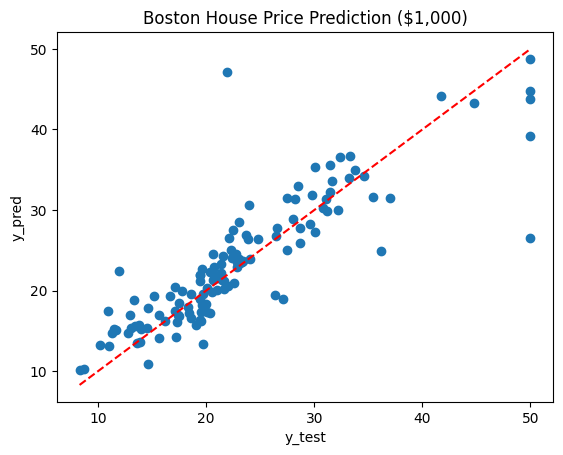

In [14]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], '--', c='r')
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.title('Boston House Price Prediction ($1,000)')
plt.show()

## 실습

### UCI Machine Learning Repository 의 Auto MPG dataset 을 사용하여 자동차 연비 예측 Regression model 작성

- auto-mpg.data - data file  


- auto-mpg.names - data 설명 file

    1. mpg:           continuous  
    2. cylinders:     multi-valued discrete  
    3. displacement:  continuous (배기량)   
    4. horsepower:    continuous  
    5. weight:        continuous  
    6. acceleration:  continuous  
    7. model year:    multi-valued discrete  
    8. origin:        multi-valued discrete, 1 - USA, 2 - Europe, 3 - Japan  
    9. car name:      string (unique for each instance)  

Missing Attribute Values:  horsepower has 6 missing values  ==> "?" 로 들어 있으므로 read_csv 시 nan 으로 변환

필요한 라이브러리를 import 합니다. Auto MPG 데이터셋을 사용하여 자동차 연비 예측 모델을 구축합니다.

In [20]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Data load 및 Preprocessing

Auto MPG 데이터셋을 다운로드하고 로드합니다. horsepower 컬럼의 결측값("?")을 na_values로 지정하여 NaN으로 변환합니다.

In [21]:
# TensorFlow에서 제공하는 유틸리티 함수로 데이터 파일 다운로드
data_path = tf.keras.utils.get_file(
    "auto-mpg.data",
    "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
)

# Auto MPG 데이터셋의 각 컬럼 이름 정의
# mpg: 연비 (목표 변수)
# 나머지 컬럼: 자동차의 물리적/엔진 특성
column_names = [
    'mpg',           # 연비 (miles per gallon)
    'cylinders',     # 실린더 수
    'displacement',  # 배기량
    'horsepower',    # 마력
    'weight',        # 차량 무게
    'acceleration',  # 가속도
    'model year',    # 출시 연도
    'origin'         # 제조 국가 코드
]

# Pandas로 원본 데이터 파일 읽기
rawdata = pd.read_csv(
    data_path,                           # 다운로드된 데이터 파일 경로
    names=column_names,      # 컬럼 이름 지정
    na_values="?",                    # '?' 문자를 결측치(NaN)로 처리
    comment="\t",                      # 탭 문자로 시작하는 줄은 주석으로 간주
    sep=" ",                                # 공백을 기준으로 컬럼 구분
    skipinitialspace=True          # 연속된 공백 무시
)

# 데이터의 상위 5개 행 확인
rawdata.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


결측값이 있는 행을 제거하고, 범주형 변수(cylinders, origin)를 원-핫 인코딩으로 변환합니다. 그 다음 타겟 변수(mpg)를 분리하고 데이터를 훈련/테스트 세트로 나눕니다.

In [22]:
# 결측치(NaN)가 포함된 행을 모두 제거
rawdata.dropna(inplace=True)

# 원본 데이터를 보존하기 위해 복사본 생성
data = rawdata.copy()

# 범주형 변수(cylinders, origin)를 원-핫 인코딩(one-hot encoding)으로 변환
# - 숫자이지만 범주 의미를 가지는 변수이므로 더미 변수로 처리
data = pd.get_dummies(
    data,
    columns=['cylinders', 'origin']
)

# 예측 대상 변수(mpg, 연비)를 feature 데이터에서 분리
label = data.pop('mpg')

# 전체 데이터를 학습용(train)과 테스트용(test)으로 분리
X_train, X_test, y_train, y_test = train_test_split(data.values, label.values)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((294, 13), (98, 13), (294,), (98,))

StandardScaler를 사용하여 특성을 표준화합니다. 평균 0, 표준편차 1로 정규화하여 모델 학습의 안정성을 높입니다.

In [23]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Regression Model Build

### train

### predict

### $r^2$ 계산

### 시각화